In [1]:
import os
import torch
import torch.nn.functional
import torchvision
import torchvision.transforms as transforms
import numpy as np
import cv2
import matplotlib.pyplot as plt
from tqdm import tqdm

from utils_week13 import LeNet5

In [2]:
epoches = 4000
learning_rate = 1e-2
batch_size = 128
LAMBDA = 1e-3
PIXEL_MIN = 0.0
PIXEL_MAX = 1.0

## 样本重建攻击
- 请大家按照ppt介绍的基于输出重建图像的方法，实现output_loss（让输出接近目标类别）与TV_loss（让输入更加平滑），完成样本重建攻击
- 为保证实验效果，请大家不要更换optimizer、learning_rate以及epoches
  

- 实验技巧：（有助于借助错位简化TV_loss的计算）
    - 使用【:】操作符，控制数组的取值范围，以一维数组a = Tensor([1, 2, 3, 4])为例
        - a[:]，即保留a第一维从起始下标到终止下标的所有元素
            - a[:] = Tensor([1, 2, 3, 4])
        - a[start:]，即保留a第一维从下标start到终止下标的所有元素
            -a[1:] = Tensor([2, 3, 4])
        - a[:end]，即保留a第一维从起始下标到下标end的所有元素（不包含下标end）
            -a[:2] = Tensor([1, 2])
        - a[start:end]，即保留a第一维从下标start到到下标end的所有元素（不包含下标end）
            -a[1:3] = Tensor([2, 3])
- 实验可能使用到的一些函数：
    - torch.sum(input, dim)：计算input所有元素的和
    - torch.pow(input, d)：对input中每个元素计算其d次方的计算结果

In [3]:
model = LeNet5()
model.load_state_dict(torch.load('./model/lenet5.pt'))

save_file = 'lenet5_reconstruction'
if not os.path.exists(save_file):
    os.makedirs(save_file)
    
def tensor_size(x):
    return x.shape[-1] * x.shape[-2]

In [4]:
correct = 0.
for target_y in range(10):
    print(f"Reconstruction for class {target_y}")
    target_y = torch.tensor(target_y)
    target_output = torch.nn.functional.one_hot(target_y, num_classes=10).float().unsqueeze(0)

    # 初始化图像: [batch, channel, h, w]
    x = torch.zeros(1, 1, 28, 28)
    x.requires_grad = True
    # NOTE: MNIST图像由ToTensor()转换得到，合法像素范围为[0, 1]
    
    # NOTE: 可基于重建效果为output_loss选择不同criterion
    criterion = torch.nn.MSELoss(reduction='mean')
    
    optimizer = torch.optim.Adam([x], lr=learning_rate)
    with torch.no_grad():
        prediction = model(x)
        original_diff = criterion(torch.softmax(prediction, dim=1), target_output)
        print(f"Begin Diff = {original_diff}")
    
    pbar = tqdm(range(1, epoches + 1))
    for epoch in pbar:
        # TODO：模型预测，计算基于输出相似度的output_loss和TV_loss
        
        output_loss = criterion(torch.softmax(model(x), dim=1), target_output)
        # sum up (x[i+1,j] - x[i,j])^2 / (h-1)*w and (x[i,j+1] - x[i,j])^2 / h*(w-1) for all valid i, j
        TV_loss = 2 * torch.sum(torch.pow(x[:, :, 1:, :] - x[:, :, :-1, :], 2)) / ((x.shape[2] - 1) * x.shape[3]) + torch.sum(torch.pow(x[:, :, :, 1:] - x[:, :, :, :-1], 2)) / (x.shape[2] * (x.shape[3] - 1))

        loss = output_loss + LAMBDA * TV_loss
        #TODO：反传梯度，更新重建图像 x
        #TODO：更新后将重建图像 x 限制在合法像素范围[0, 1]
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        with torch.no_grad():
            x.clamp_(PIXEL_MIN, PIXEL_MAX)

        pbar.set_description(f"loss = {loss.detach():.6f}")

    # 验证重建后的图像标签
    with torch.no_grad():
        prediction = model(x)
        final_diff = criterion(torch.softmax(prediction, dim=1), target_output)
        print(f"Final Diff = {final_diff}")
    print(f"Target y = {target_y}, prediction = {torch.argmax(torch.softmax(prediction, dim=1), dim=1).item()}")
    if target_y == torch.argmax(torch.softmax(prediction, dim=1), dim=1).item(): correct += 1
    
    x_np = x.detach().numpy()
    
    img = x_np[0][0]
    img = cv2.resize(img, dsize=(200, 200), interpolation=cv2.INTER_NEAREST)
    img = np.clip(img, PIXEL_MIN, PIXEL_MAX)
    img = np.uint8(img * 255)
    
    save_path = f"{save_file}/y={target_y}_avg.png"
    cv2.imwrite(save_path, img)
    print(f"Saved reconstructed image in {save_path}\n")

Reconstruction for class 0
Begin Diff = 0.0957324206829071


  0%|          | 0/4000 [00:00<?, ?it/s]

loss = 0.000009: 100%|██████████| 4000/4000 [00:05<00:00, 745.21it/s]


Final Diff = 1.5443835081896395e-06
Target y = 0, prediction = 0
Saved reconstructed image in lenet5_reconstruction/y=0_avg.png

Reconstruction for class 1
Begin Diff = 0.08703777194023132


loss = 0.000011: 100%|██████████| 4000/4000 [00:05<00:00, 710.97it/s]


...

Final Diff = 9.805844456423074e-07
Target y = 7, prediction = 7
Saved reconstructed image in lenet5_reconstruction/y=7_avg.png

Reconstruction for class 8
Begin Diff = 0.09049932658672333


loss = 0.000003: 100%|██████████| 4000/4000 [00:06<00:00, 629.07it/s]


Final Diff = 7.414842002617661e-07
Target y = 8, prediction = 8
Saved reconstructed image in lenet5_reconstruction/y=8_avg.png

Reconstruction for class 9
Begin Diff = 0.08906363695859909


loss = 0.000007: 100%|██████████| 4000/4000 [00:06<00:00, 573.08it/s]

Final Diff = 1.3388623756327434e-06
Target y = 9, prediction = 9
Saved reconstructed image in lenet5_reconstruction/y=9_avg.png



- 统计预测成功率

In [5]:
succ_ratio = float(correct/10)*100
print(f"Acc = {succ_ratio:.2f}%")

Acc = 100.00%


- 可视化图像

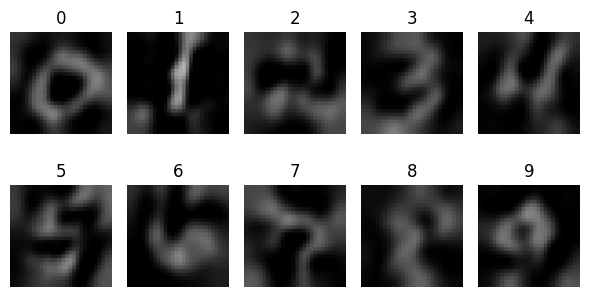

In [6]:
# 如果jupyter内核崩溃加下面两行
# import os
# os.environ['KMP_DUPLICATE_LIB_OK']='True'
fig = plt.figure(figsize=(6, 4))

files = os.listdir(save_file)
for file in files:
    y = file.split('=')[-1].split('_')[0]
    img = cv2.imread(f"{save_file}/{file}")
    
    ax = fig.add_subplot(2, 5, int(y)+1)
    
    ax.set_title(y)
    ax.set_axis_off()
    plt.imshow(img)
    plt.tight_layout()